In [6]:
#　不安定域の分布作成　
#　　GSM(grib2形式)を使って、次の物理量を表示する数値予報天気図
#　・上層の飽和相当温位 と　下層の最大の相当温位との差
#　・上層の気温
import math
import pygrib
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.path as mpath
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import datetime
import sys
#                                                                                          
import metpy.calc as mpcalc
from metpy.units import units

In [7]:
# GSMの読み込む初期値の年月日時をUTCで与えます。
i_year =2021
i_month = 8
i_day = 13
i_hourZ = 18
#
# 予想時間を与える。この値は注意が必要です。下3桁目が日数、下２桁で時間で与えます。
#  初期値なら0、18時間後なら18、24時間後なら100、36時間後なら112となります。
i_ft = 0
#
#  時間に変換
ft_hours=int(i_ft/100) * 24 + int(i_ft%100)
#
#　上層の気圧面を指定
preTop=300
#　下層Topの気圧面を指定、下層の下端は1000hPaと固定
preLow=850
#
# 天気図の表示範囲指定
areaAry = [115, 151, 20, 50]
#
# データの格納先フォルダー名
##!!! GRIB2データの保存先をFolderを指定すること !!!
data_fld="./data/gsm/"
#
####################################################
#
## データ読み込み部
# 読み込むGRIB2形式GSMのファイル名
gsm_fn_t="Z__C_RJTD_{0:4d}{1:02d}{2:02d}{3:02d}0000_GSM_GPV_Rgl_FD{4:04d}_grib2.bin"
gr_fn= gsm_fn_t.format(i_year,i_month,i_day,i_hourZ,i_ft)
#
# データOpen GSMのGRIB2ファイル名を指定
grbs = pygrib.open(data_fld + gr_fn)
#
# データ読み込み。 要素毎に、tagHpの等圧面から下部のデータをいっきに読み込みます。
# 高度
grbHt = grbs(shortName="gh",typeOfLevel='isobaricInhPa',
             level=lambda l:l >= preLow or l == preTop)
# 気温
grbTm = grbs(shortName="t",typeOfLevel='isobaricInhPa',
             level=lambda l:l >= preLow or l == preTop)
# 相対湿度
grbRh = grbs(shortName="r",typeOfLevel='isobaricInhPa',
             level=lambda l:l >= preLow or l == preTop)
#                                                                        
## データ時刻取得                                                        
dt = grbHt[0].validDate
dt_i = grbHt[0].analDate
dt_str = (dt_i.strftime("%H00UTC%d%b%Y")).upper()
dt_str2 = dt_i.strftime("%Y%m%d%H")
print(dt_str)

1800UTC13AUG2021


In [9]:
## grbデータの3次元データ化     
# GPVの緯度・傾度の1次元配列 の 取得                                       
lats2, lons2 = grbHt[0].latlons()
lats = lats2[:,0]
lons = lons2[0,:]
# GPVのレベルの配列 の 取得
levels = np.array([g['level'] for g in grbHt])
indexes = np.argsort(levels)[::-1]
# GPVの2次元データの格子数　の　取得
x, y = grbHt[0].values.shape
#                    
# 要素毎の3次元データの配列作成と0に初期化                                                
cubeHt = np.zeros([len(levels), x, y])
cubeTm = np.zeros([len(levels), x, y])
cubeRh = np.zeros([len(levels), x, y])
for i in range(len(levels)):
    cubeHt[i,:,:] = grbHt[indexes[i]].values
    cubeTm[i,:,:] = grbTm[indexes[i]].values
    cubeRh[i,:,:] = grbRh[indexes[i]].values
#
## 3次元データのDataset作成                                                  
ds = xr.Dataset(
    {
        "Geopotential_height": (["level","lat", "lon"], cubeHt * units.meter),
        "temperature": (["level","lat", "lon"], cubeTm * units('K')),
        "relative_humidity": (["level","lat", "lon"], cubeRh * units('%')),
    },
    coords={
        "level": levels,
        "lat": lats,
        "lon": lons,
        "time": [grbHt[0].validDate],
    },
)
ds['Geopotential_height'].attrs['units'] = 'm'
ds['temperature'].attrs['units']='K'
ds['relative_humidity'].attrs['units']='%'
ds['level'].attrs['units'] = 'hPa'
ds['lat'].attrs['units'] = 'degrees_north'
ds['lon'].attrs['units'] = 'degrees_east'


In [11]:
## 露点温度　計算                                                                 
ds['dewpoint_temperature'] = mpcalc.dewpoint_from_relative_humidity(
  ds['temperature'],ds['relative_humidity'])
ds['dewpoint_temperature'].attrs['units']='K'
## 相当温位　計算
ds['ept'] = mpcalc.equivalent_potential_temperature(
  ds['level'] * units('hPa'), ds['temperature'], ds['dewpoint_temperature'])
ds['ept'].attrs['units']='K'
##　飽和相当温位　計算
ds['sept'] = mpcalc.saturation_equivalent_potential_temperature(
  ds['level'], ds['temperature'])
ds['sept'].attrs['units']='K'

In [12]:
## ds['ept'][0]に、ds['ept'][下層]の最大値を代入する !!! 
# 計算処理遅い高速化必要!                                                         
for i in np.arange(len(levels) - 2):
    print(i)
    for j in np.arange(len(lats)):
        for k in np.arange(len(lons)):
            e0 = ds['ept'][0].values[j][k]
            e1 = ds['ept'][i+1].values[j][k]
            if (e1 > e0):
                ds['ept'][0].values[j][k] = e1
#print(ds['ept'][0].values.max())                                               

0
1


Found valid latitude/longitude coordinates, assuming latitude_longitude for projection grid_mapping variable
Found valid latitude/longitude coordinates, assuming latitude_longitude for projection grid_mapping variable
Found valid latitude/longitude coordinates, assuming latitude_longitude for projection grid_mapping variable
Found valid latitude/longitude coordinates, assuming latitude_longitude for projection grid_mapping variable
Found valid latitude/longitude coordinates, assuming latitude_longitude for projection grid_mapping variable
Found valid latitude/longitude coordinates, assuming latitude_longitude for projection grid_mapping variable


Found valid latitude/longitude coordinates, assuming latitude_longitude for projection grid_mapping variable
Found valid latitude/longitude coordinates, assuming latitude_longitude for projection grid_mapping variable
Found valid latitude/longitude coordinates, assuming latitude_longitude for projection grid_mapping variable
Found valid latitude/longitude coordinates, assuming latitude_longitude for projection grid_mapping variable
Found valid latitude/longitude coordinates, assuming latitude_longitude for projection grid_mapping variable
Found valid latitude/longitude coordinates, assuming latitude_longitude for projection grid_mapping variable


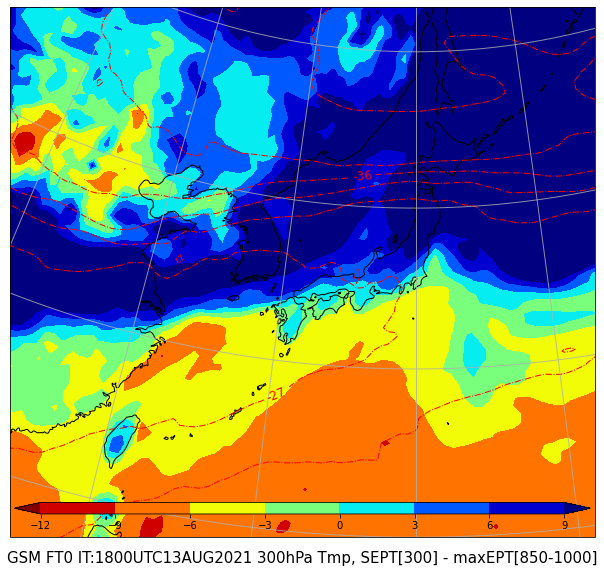

In [15]:
## Parse full dataset                                                           
dsp= ds.metpy.parse_cf()
#                                                                               
## 図のSIZE指定inch                                                             
fig = plt.figure(figsize=(10,8))
## 余白設定                                                                     
plt.subplots_adjust(left=0, right=1, bottom=0.06, top=0.98)
## 図法指定                                                                     
proj = ccrs.Stereographic(central_latitude=60, central_longitude=140)
latlon_proj = ccrs.PlateCarree() # 緯度経度の処理用に正距円筒図法も使う         
## 作図                                                                         
ax = fig.add_subplot(1, 1, 1, projection=proj)
ax.set_extent(areaAry, latlon_proj)  #FEAX                                      
# ax.set_extent([105,180,0,65])  #ASASの範囲                                    
## sept[preTop] - max(ept[preLow - 1000])                                       
cnf_dept = ax.contourf(dsp['lon'], dsp['lat'],
                       dsp['sept'][len(levels) -1] - dsp['ept'][0],
                       np.arange(-12,12,3), cmap="jet_r", extend='both',
                       transform=latlon_proj )
# colorbarの位置と大きさ指定                                                    
#  add_axes([左端の距離, 下端からの距離, 横幅, 縦幅])                           
ax_ept = fig.add_axes([0.1, 0.1, 0.8, 0.02])
cb_ept = fig.colorbar(cnf_dept, orientation='horizontal', shrink=0.74,
                      aspect=40, pad=0.01, cax=ax_ept)
# 温度線 実線                                                                   
levels_tmp=np.arange(-60,30,3)
cn_tmpTop = ax.contour(dsp['lon'], dsp['lat'],
                      dsp['temperature'][len(levels)-1] - 273.15 * units('K'),
                      colors='red', linewidths=1.0, linestyles='dashdot',
                      levels=levels_tmp,transform=latlon_proj )
ax.clabel(cn_tmpTop, levels_tmp, fontsize=12,
          inline=True, inline_spacing=5, colors='red',
          fmt='%i', rightside_up=True)
#
ax.coastlines(resolution='50m',) # 海岸線の解像度を上げる                       
# グリッド線を引く                                                              
dlon,dlat=10,10
xticks=np.arange(0,360.1,dlon)
yticks=np.arange(-90,90.1,dlat)
gl = ax.gridlines(crs=ccrs.PlateCarree()
         , draw_labels=False
         , linewidth=1, alpha=0.8)
gl.xlocator = mticker.FixedLocator(xticks)
gl.ylocator = mticker.FixedLocator(yticks)
#sw                                      
fig.text(0.5,0.01,"GSM FT{0:d} IT:".format(ft_hours)+dt_str+" {0}hPa Tmp, SEPT[{0}] - maxEPT[{1}-1000]".format(int(preTop),int(preLow)) ,ha='center',va='botto\
m', size=15)
plt.show()                   